<a href="https://colab.research.google.com/github/abrar2akib/Sample-Codes/blob/main/Monte%20Carlo%20Simulation/ICPRE%202026/12_Projects_monte_carlo_(ICPRE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total scenarios generated: 1,152
  (12 projects × 96 combinations; FX always True per contract)

Running Monte Carlo...
  Simulations: 500 | Bootstraps: 500 | Years: 20
  Estimated runtime: ~0–1 minutes on Colab

  [ 100/1152] Ph1_Pkg1_Noakhali | sec=Baseline tar=levelized   bal=True  par=True  fx=True  inf=True  Det.NPV=$-7.50M
  [ 200/1152] Ph1_Pkg2_HathHazari | sec=Baseline tar=levelized   bal=False par=True  fx=True  inf=True  Det.NPV=$-16.41M
  [ 300/1152] Ph1_Pkg11_Fatikchari | sec=Baseline tar=front_loaded bal=True  par=True  fx=True  inf=True  Det.NPV=$-26.69M
  [ 400/1152] Ph2_B5_Jaldhaka | sec=Baseline tar=front_loaded bal=False par=True  fx=True  inf=True  Det.NPV=$-34.87M
  [ 500/1152] Ph2_B8_Bibiyana | sec=Baseline tar=back_loaded bal=True  par=True  fx=True  inf=True  Det.NPV=$-24.35M
  [ 600/1152] Ph3_C1_Ishwardi | sec=Baseline tar=back_loaded bal=False par=True  fx=True  inf=True  Det.NPV=$-40.76M
  [ 700/1152] Ph3_C6_CoxsBazarN | sec=LC       tar=levelized   bal=True  

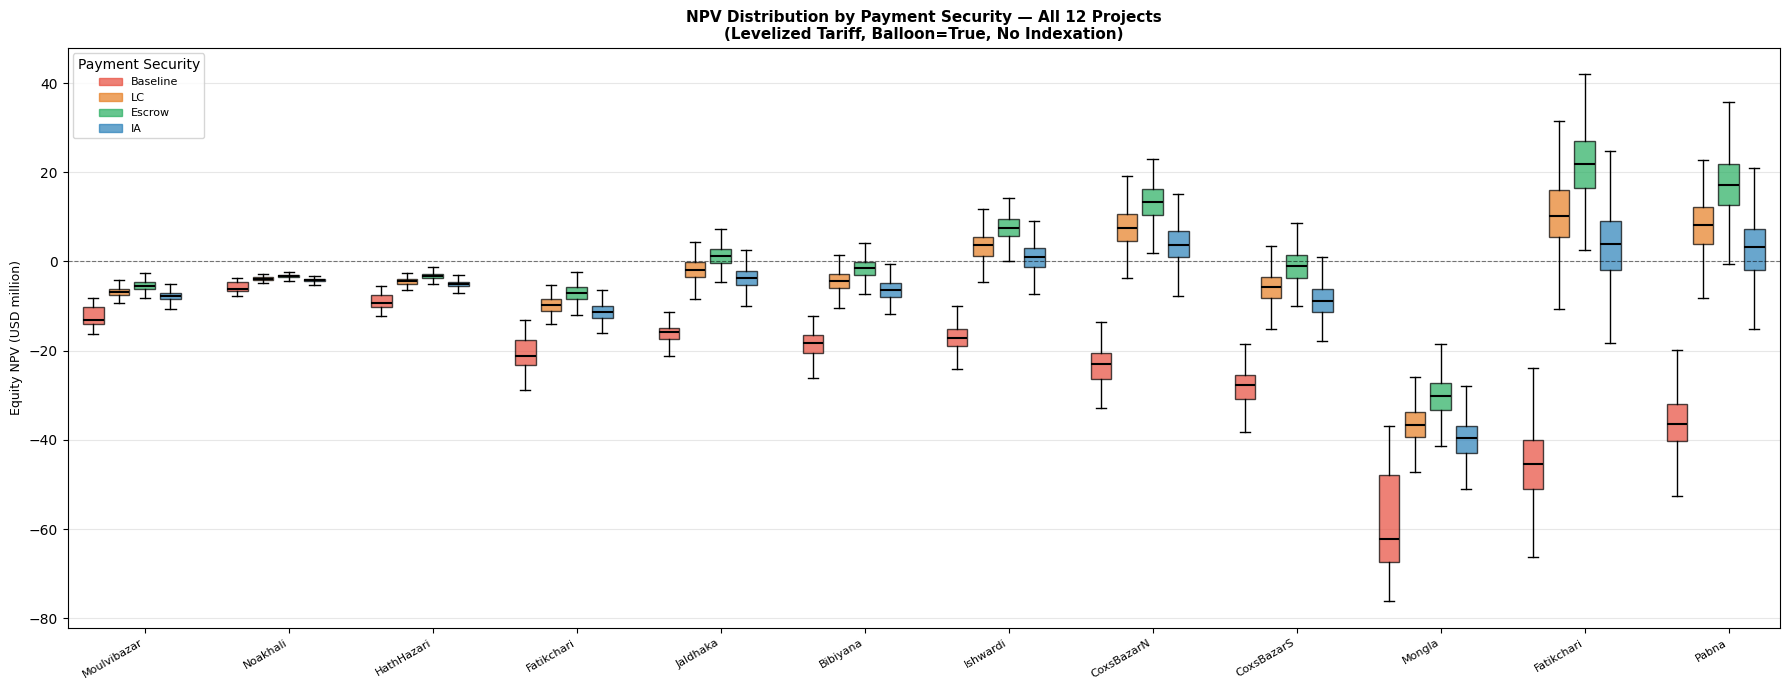

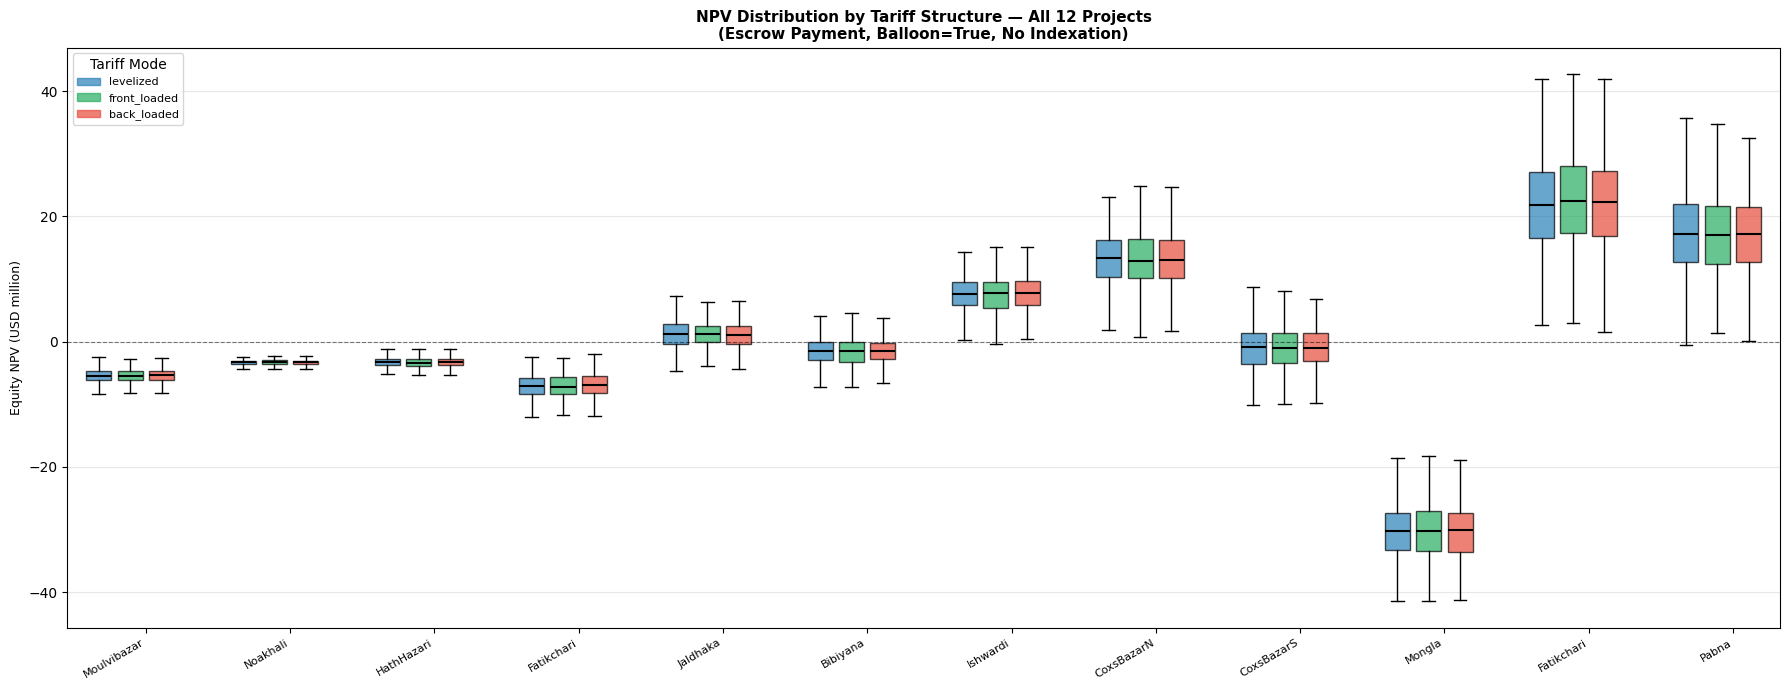

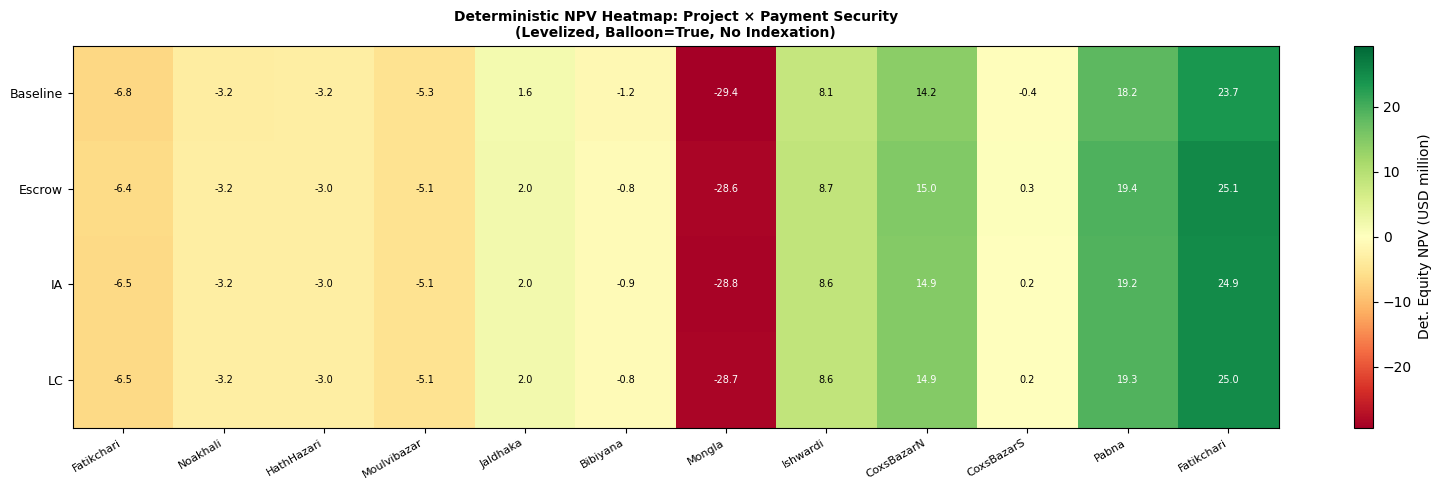

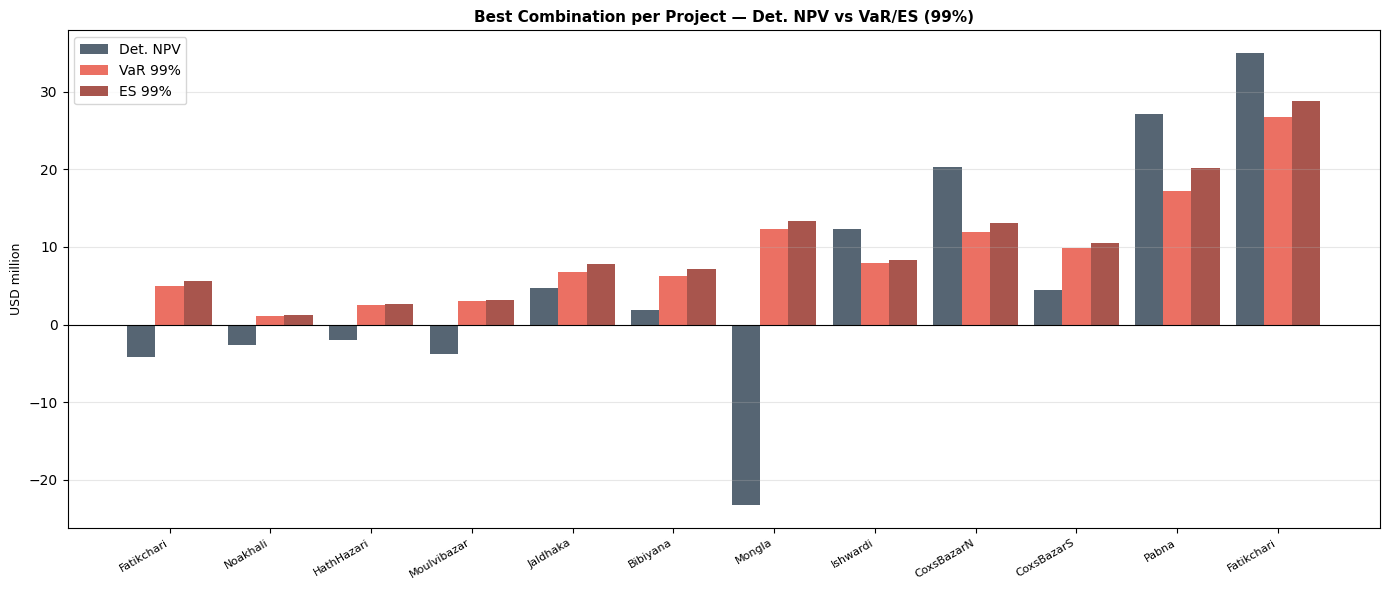

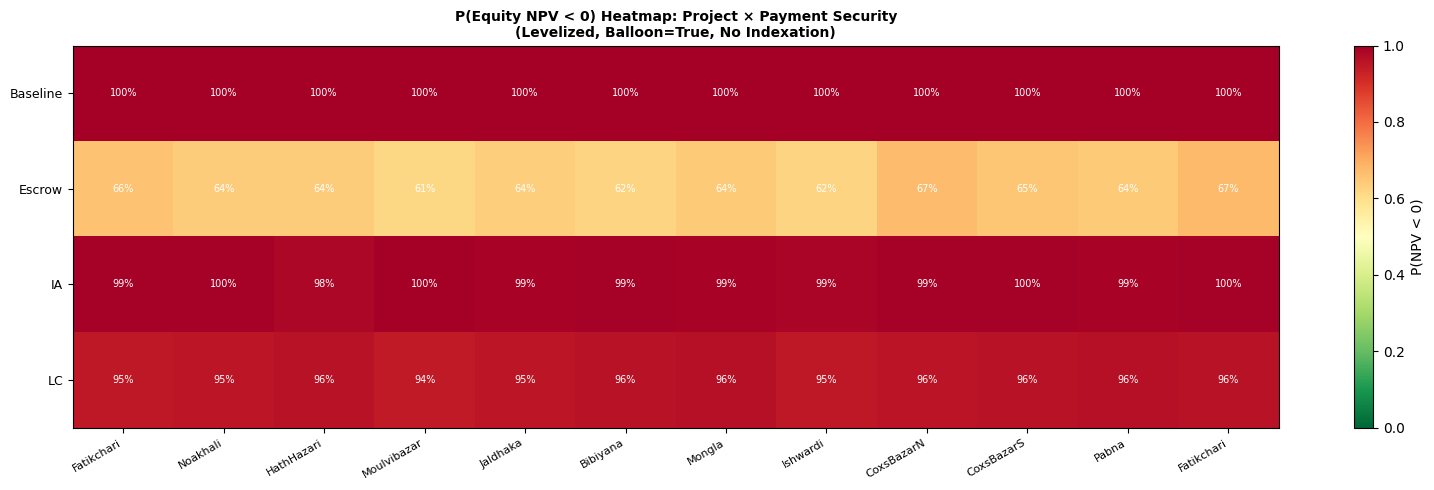

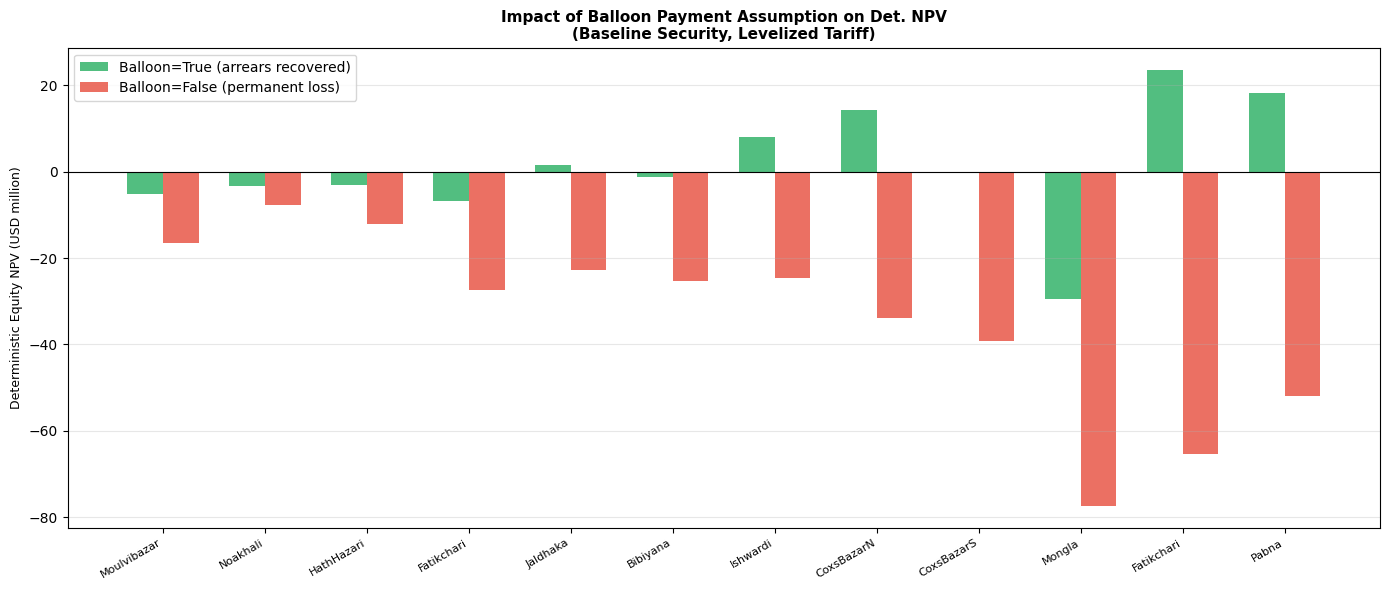



Files saved:
  12projects_var_es_results.csv   — full results (2,304 rows = 1,152 scenarios × 2 alphas)
  chart1_security_all_projects.pdf
  chart2_tariff_all_projects.pdf
  chart3_npv_heatmap.pdf
  chart4_best_combo_var_es.pdf
  chart5_pneg_heatmap.pdf
  chart6_balloon_impact.pdf


In [ ]:
# -*- coding: utf-8 -*-
"""12 Projects Monte Carlo

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1VyKzy6SuN7OVlZsYshfD9NQyiZ9RqqxY
"""

# -*- coding: utf-8 -*-
"""
12 Projects MC
==============
Monte Carlo VaR & ES for 12 real Bangladesh solar PPA projects.
Each project runs 96 combinations:
  Payment security (4) × Tariff mode (3) × Balloon (2) × Partial pay (2)
  × FX indexation (1, contract-validated always True) × Inflation indexation (2)  =  96 per project
  × 12 projects  =  1,152 scenarios total

Key contract provisions implemented (Sections 1, 2, 3, 4, 6, 8, 9 modified):
  - FX tariff split: TP_m = TR(Local)×NEO_m + TR(Foreign)×NEO_m×CE_m  [PPA §2.1(i)]
  - True-Up for Exchange Rate: Tup = TPm × ((CE_invoice/CE_m) − 1)     [PPA §2.1(ii)]
  - Late Payment Surcharge: 1% p.a. on overdue invoice principal        [PPA §Late Payment]
  - Price Adjustment on delay: toggle (False per contract — no mechanism
    for adjusting invoice amounts during payment delay period)           [PPA §62]
  - FX indexation is always True (contract-validated); False scenario removed.

Sections 5, 7 and chart logic in Section 10 are UNCHANGED.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

np.random.seed(42)

# ============================================================
#  SECTION 1: ALL INPUT PARAMETERS
# ============================================================

# --- Simulation controls ---
YEARS        = 20
SIMULATIONS  = 500    # reduced from 10k to keep runtime manageable (2304 scenarios)
BOOTSTRAPS   = 500      # reduced proportionally
HOURS_PER_YEAR = 8_760

# --- 12 Real Projects (Phase, Package, Location, Capacity, Tariff, CAPEX/MW all-in) ---
# CAPEX/MW estimated by Gemini using Bangladesh context + area/phase analysis (all-in USD)
# Tariff converted: cent/kWh × 10 = USD/MWh
PROJECTS = {
    'Ph1_Pkg4_Moulvibazar':    {'capacity_mw':  25, 'tariff_usd_mwh':  76.6, 'capex_usd_per_mw': 1_250_000, 'phase': 1, 'package': '4',  'location': 'Moulvibazar',    'tenderer': 'Paramount Textile'},
    'Ph1_Pkg1_Noakhali':       {'capacity_mw':  10, 'tariff_usd_mwh':  74.9, 'capex_usd_per_mw': 1_350_000, 'phase': 1, 'package': '1',  'location': 'Sudharam Noakhali','tenderer': 'Maheen Vidullanka JV'},
    'Ph1_Pkg2_HathHazari':     {'capacity_mw':  18, 'tariff_usd_mwh':  83.2, 'capex_usd_per_mw': 1_300_000, 'phase': 1, 'package': '2',  'location': 'Hath Hazari',     'tenderer': 'FGL/FHL/GBB Consortium'},
    'Ph1_Pkg11_Fatikchari':    {'capacity_mw':  45, 'tariff_usd_mwh':  77.7, 'capex_usd_per_mw': 1_200_000, 'phase': 1, 'package': '11', 'location': 'Fatikchari',      'tenderer': 'Karnaphuli-Infraco'},
    'Ph2_B5_Jaldhaka':         {'capacity_mw':  50, 'tariff_usd_mwh':  82.6, 'capex_usd_per_mw': 1_050_000, 'phase': 2, 'package': 'B5', 'location': 'Jaldhaka',        'tenderer': 'Concord Pragati'},
    'Ph2_B8_Bibiyana':         {'capacity_mw':  50, 'tariff_usd_mwh':  81.3, 'capex_usd_per_mw': 1_100_000, 'phase': 2, 'package': 'B8', 'location': 'Bibiyana',        'tenderer': 'Paramount Textile'},
    'Ph3_C1_Ishwardi':         {'capacity_mw':  70, 'tariff_usd_mwh':  79.0, 'capex_usd_per_mw':   900_000, 'phase': 3, 'package': 'C1', 'location': 'Ishwardi',        'tenderer': 'Paramount Textile'},
    'Ph3_C6_CoxsBazarN':       {'capacity_mw': 100, 'tariff_usd_mwh':  80.9, 'capex_usd_per_mw':   900_000, 'phase': 3, 'package': 'C6', 'location': "Cox's Bazar N",   'tenderer': 'Confidence'},
    'Ph3_C7_CoxsBazarS':       {'capacity_mw': 100, 'tariff_usd_mwh':  65.3, 'capex_usd_per_mw':   850_000, 'phase': 3, 'package': 'C7', 'location': "Cox's Bazar S",   'tenderer': 'China North East EPE'},
    'Ph3_C13_Mongla':          {'capacity_mw': 100, 'tariff_usd_mwh':  80.9, 'capex_usd_per_mw': 1_430_000, 'phase': 3, 'package': 'C13','location': 'Mongla',          'tenderer': 'Confidence & Doreen'},
    'Ph4_D7_Fatikchari':       {'capacity_mw': 200, 'tariff_usd_mwh':  75.0, 'capex_usd_per_mw':   850_000, 'phase': 4, 'package': 'D7', 'location': 'Fatikchari',      'tenderer': 'Confidence'},
    'Ph4_D14_Pabna':           {'capacity_mw': 150, 'tariff_usd_mwh':  78.9, 'capex_usd_per_mw':   900_000, 'phase': 4, 'package': 'D14','location': 'Pabna',           'tenderer': 'Paramount'},
}

# --- Capacity factor & degradation ---
BASELINE_CF          = 0.23
CF_DEGRADATION_Y1    = 0.02
CF_DEGRADATION_ANNUAL= 0.0045
CAPACITY_CF_SD       = 0.03
CF_CLIP_LOWER        = 0.004
CF_CLIP_UPPER        = 1.35

# --- Payment behaviour ---
PAYMENT_PROB_MONTHLY = {
    'Baseline': 0.50,
    'LC':       0.90,
    'Escrow':   0.98,
    'IA':       0.85,
}
BALLOON_PAYMENT_AT_END  = True   # module-level default (overridden per scenario)
STRESS_TRIGGER_MONTHS   = 6
DSCR_GRACE_PERIOD_YEARS = 5
PARTIAL_PAYMENT_ALLOWED = False
BETA_A = 5
BETA_B = 5

# --- O&M ---
OM_USD_PER_MW_BASE = 12_300.0
OM_SCALE_EXPONENT  = -0.10
OM_PROFILE = {'early': 0.50, 'mid': 1.00, 'late': 1.40}
OM_COST_SD = 0.15

# --- Financing (shared across all projects) ---
DEBT_EQUITY_RATIO  = 0.70
DEBT_TENOR_YEARS   = 20
DEBT_INTEREST_RATE = 0.065
WACC               = 0.105

# --- FX & Inflation ---
# FX indexation is always True per PPA §2.1(i): tariff is split into local (BDT) and
# foreign (USD) components. The foreign portion is re-valued each month at the Sonali Bank
# spot rate (CE_m), providing full FX pass-through on the foreign tranche.
FX_INDEXATION          = True    # Contract-validated; False scenario not applicable
INFLATION_INDEXATION   = False   # Toggle; no explicit CPI escalation clause modelled yet
FX_ANNUAL_DEPRECIATION = 0.05   # Expected annual BDT/USD depreciation (used for stochastic draws)
INFLATION_RATE         = 0.06
# TR(Foreign) share of total tariff — the remainder is TR(Local) denominated in BDT.
# Assumed 50% foreign / 50% local split (typical Bangladesh solar PPA structure).
FX_FOREIGN_SHARE       = 0.50   # fraction of tariff that is USD-denominated [PPA §2.1(i)]

# --- Late Payment Surcharge  [PPA §Late Payment Surcharge] ---
# All late payments bear interest at 1% per annum, computed on actual overdue days,
# on a 365-day year basis.  In the monthly simulation this translates to:
#   surcharge_rate_monthly = 0.01 / 12
LATE_PAYMENT_SURCHARGE_RATE = 0.01   # 1% p.a. per PPA contract

# --- Price Adjustment on Payment Delay  [PPA §62] ---
# The PPA contract has NO price-adjustment mechanism for the period of payment delay
# (i.e. delayed invoices are settled at the original invoice amount — no inflation
# uplift applies to the unpaid principal during the delay period).
# Set to True only if a future contract revision introduces such a mechanism.
PRICE_ADJUSTMENT_ON_DELAY = False    # False = contract-compliant (no adjustment on arrears)

# ============================================================
#  SECTION 2: DERIVED QUANTITIES  (UNCHANGED)
# ============================================================

def annuity(r, n):
    if abs(r) < 1e-12:
        return 1.0 / n
    return r / (1 - (1 + r) ** (-n))

def om_for_year(t, capacity_mw):
    scale = (capacity_mw / 100.0) ** OM_SCALE_EXPONENT
    base  = OM_USD_PER_MW_BASE * scale * capacity_mw
    if t <= 5:
        return base * OM_PROFILE['early']
    elif t <= 12:
        return base * OM_PROFILE['mid']
    else:
        return base * OM_PROFILE['late']

def degraded_cf_mean(t):
    if t == 1:
        return BASELINE_CF
    cf = BASELINE_CF - CF_DEGRADATION_Y1
    cf -= CF_DEGRADATION_ANNUAL * (t - 2)
    return max(cf, 0.05)

def tariff_schedule(mode, years=YEARS, base_tariff=None):
    """
    Returns list of per-year tariff values.
    base_tariff is passed explicitly so each project uses its own tariff.
    front_loaded: starts 1.10× base, declines 0.5%/yr
    levelized:    flat
    back_loaded:  starts 0.90× base, grows 0.5%/yr
    """
    tariffs = []
    for yr in range(1, years + 1):
        if mode == 'front_loaded':
            t = base_tariff * 1.10 * ((1 - 0.005) ** (yr - 1))
        elif mode == 'back_loaded':
            t = base_tariff * 0.90 * ((1 + 0.005) ** (yr - 1))
        else:
            t = base_tariff
        tariffs.append(t)
    return tariffs

def simulate_payment_queue(payment_prob_monthly, years=YEARS,
                           partial_pay=False, balloon=BALLOON_PAYMENT_AT_END):
    """FIFO payment queue — UNCHANGED from ppa_monte_carlo_revised.py.
    Returns revenue_frac_by_year, stressed_year, avg_delay, delay_months_by_year.
    delay_months_by_year is added to support late payment surcharge calculation [PPA §Late Payment].
    """
    total_months      = years * 12
    queue             = []
    cash_by_month     = np.zeros(total_months)
    consec_fail       = 0
    stressed_flag     = False
    stressed_by_month = np.zeros(total_months, dtype=bool)
    paid_delays       = []
    # Track sum of (invoice_amount × delay_months) for surcharge computation
    delay_invoice_months_by_month = np.zeros(total_months)  # [PPA §Late Payment]

    for m in range(total_months):
        queue.append([m, 1.0])
        cleared_this_month = False
        if queue and np.random.rand() < payment_prob_monthly:
            if partial_pay:
                frac = np.clip(np.random.beta(BETA_A, BETA_B), 0.05, 1.0)
                inv  = queue[0]
                cash_by_month[m] += frac * inv[1]
                inv[1] -= frac * inv[1]
                if inv[1] < 0.01:
                    delay_m = m - inv[0]
                    paid_delays.append(delay_m)
                    delay_invoice_months_by_month[m] += inv[1] * delay_m  # weighted delay
                    queue.pop(0)
                cleared_this_month = True
            else:
                inv = queue.pop(0)
                delay_m = m - inv[0]
                cash_by_month[m] += inv[1]
                paid_delays.append(delay_m)
                delay_invoice_months_by_month[m] += inv[1] * delay_m  # weighted delay [PPA §Late Payment]
                cleared_this_month = True

        if cleared_this_month:
            consec_fail = 0
        else:
            consec_fail += 1
        if consec_fail >= STRESS_TRIGGER_MONTHS:
            stressed_flag = True
        stressed_by_month[m] = stressed_flag

    if balloon and queue:
        for inv in queue:
            delay_m = (total_months - 1) - inv[0]
            cash_by_month[-1] += inv[1]
            paid_delays.append(delay_m)
            delay_invoice_months_by_month[-1] += inv[1] * delay_m
        queue = []

    cash_by_year         = cash_by_month.reshape(years, 12).sum(axis=1)
    stressed_year        = stressed_by_month.reshape(years, 12).any(axis=1)
    avg_delay            = float(np.mean(paid_delays)) if paid_delays else float(total_months)
    revenue_frac_by_year = cash_by_year / 12.0
    # Aggregate weighted delay-months per year (used for surcharge income per year)
    delay_months_by_year = delay_invoice_months_by_month.reshape(years, 12).sum(axis=1)
    return revenue_frac_by_year, stressed_year, avg_delay, delay_months_by_year

# ============================================================
#  SECTION 3: CORE SIMULATION ENGINE  (UNCHANGED logic)
# ============================================================

def simulate_npvs(scenario_params, sims=SIMULATIONS):
    """
    Core Monte Carlo engine — updated to implement contract provisions:

    FX Tariff Split [PPA §2.1(i)]:
      TP_m = TR(Local) × NEO_m  +  TR(Foreign) × NEO_m × CE_m
      Modelled as: revenue = tariff_local × gen  +  tariff_foreign × gen × fx_factor
      where fx_factor captures cumulative BDT/USD spot movement.

    True-Up for Exchange Rate [PPA §2.1(ii)]:
      If BDT depreciates between Indexation Date and payment date, contractor receives
      additional True-Up:  Tup = TP_m × ((CE_invoice / CE_m) − 1)
      In the simulation, CE_invoice > CE_m when BDT depreciates further during delay.

    Late Payment Surcharge [PPA §Late Payment]:
      Overdue invoices accrue interest at 1% p.a. on a 365-day basis.
      Per year: surcharge_income ≈ base_invoice × weighted_delay_months × (0.01/12)

    Price Adjustment on Delay [PPA §62]:
      No price-adjustment mechanism exists for delayed payments per contract.
      PRICE_ADJUSTMENT_ON_DELAY = False → arrears settled at original invoice amount.
      If True (future contract revision), O&M costs on delayed-payment years are
      inflated to reflect real erosion of purchasing power during the delay.

    All other logic (CAPEX, equity, debt service, DSCR default trigger, discounting)
    is UNCHANGED from ppa_monte_carlo_revised.py.
    """
    capacity_mw       = scenario_params['capacity_mw']
    pay_prob          = scenario_params.get('payment_prob_monthly', PAYMENT_PROB_MONTHLY['Baseline'])
    partial_pay       = scenario_params.get('partial_payment', False)
    balloon           = scenario_params.get('balloon_payment', BALLOON_PAYMENT_AT_END)
    tariff_mode       = scenario_params.get('tariff_mode', 'levelized')
    fx_index          = scenario_params.get('fx_indexation', True)   # always True per contract
    infl_index        = scenario_params.get('inflation_indexation', False)
    price_adj_on_delay= scenario_params.get('price_adjustment_on_delay', PRICE_ADJUSTMENT_ON_DELAY)
    capex_per_mw      = scenario_params['capex_usd_per_mw']
    base_tariff       = scenario_params['tariff_usd_mwh']

    capex    = capex_per_mw * capacity_mw
    debt_amt = capex * DEBT_EQUITY_RATIO
    equity   = capex - debt_amt
    ann_debt = debt_amt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)

    # Split tariff into local (BDT-fixed) and foreign (USD, re-valued at CE_m) components
    # [PPA §2.1(i)]: TR(Foreign) share = FX_FOREIGN_SHARE; TR(Local) = remainder
    tariff_foreign = base_tariff * FX_FOREIGN_SHARE
    tariff_local   = base_tariff * (1.0 - FX_FOREIGN_SHARE)

    base_tariff_schedule = tariff_schedule(tariff_mode, base_tariff=base_tariff)
    npv_list = np.zeros(sims)

    for s in range(sims):
        cf_noise    = np.random.normal(0, CAPACITY_CF_SD, size=YEARS)
        om_shocks   = np.random.lognormal(mean=0, sigma=OM_COST_SD, size=YEARS)
        # Annual BDT/USD depreciation shocks — used for CE_m simulation
        fx_shocks   = np.random.normal(FX_ANNUAL_DEPRECIATION, 0.02, size=YEARS)
        infl_shocks = np.random.normal(INFLATION_RATE, 0.01, size=YEARS) if infl_index else np.zeros(YEARS)

        rev_frac, stressed_years, avg_delay, delay_months_by_year = simulate_payment_queue(
            pay_prob, years=YEARS, partial_pay=partial_pay, balloon=balloon
        )

        cashflows         = [-equity]
        default_triggered = False
        default_year_idx  = YEARS

        # Cumulative FX depreciation factor relative to COD (used as CE_m proxy)
        cumulative_fx = 1.0

        for t_idx in range(YEARS):
            t       = t_idx + 1
            cf_t    = np.clip(degraded_cf_mean(t) + cf_noise[t_idx], CF_CLIP_LOWER, CF_CLIP_UPPER)

            # --- FX tariff computation [PPA §2.1(i)] ---
            # Cumulative spot rate factor: CE_m grows with BDT depreciation each year
            cumulative_fx *= (1.0 + fx_shocks[t_idx])
            # Effective tariff = local component (BDT-fixed, no FX uplift in USD terms
            #   → depreciates in real USD) + foreign component (USD, stable in USD terms)
            if fx_index:
                # TR(Local) in USD loses value as BDT depreciates; TR(Foreign) preserved
                tariff_t = (tariff_local / cumulative_fx) + tariff_foreign
            else:
                tariff_t = base_tariff_schedule[t_idx]

            if infl_index:
                tariff_t *= (1.0 + infl_shocks[t_idx])

            gen_mwh  = capacity_mw * HOURS_PER_YEAR * cf_t
            revenue  = tariff_t * gen_mwh
            rev_coll = revenue * rev_frac[t_idx]

            # --- True-Up for Exchange Rate [PPA §2.1(ii)] ---
            # Additional receipt when BDT depreciates further between Indexation Date
            # and actual payment date. Approximated as: Tup = rev_coll × fx_shock_t
            # (i.e. the foreign-tranche portion earns extra BDT that converts to more USD
            # when settlement occurs later at a weaker BDT rate).
            if fx_index:
                trueup_income = rev_coll * FX_FOREIGN_SHARE * fx_shocks[t_idx]
            else:
                trueup_income = 0.0

            # --- Late Payment Surcharge Income [PPA §Late Payment Surcharge] ---
            # 1% p.a. on overdue amounts; delay_months_by_year tracks weighted
            # (invoice_fraction × delay_months) settled in this year.
            # surcharge = base_monthly_invoice × weighted_delay_months × (1%/12)
            base_monthly_invoice = revenue / 12.0   # 1 unit invoice in USD
            surcharge_income = (base_monthly_invoice
                                * delay_months_by_year[t_idx]
                                * (LATE_PAYMENT_SURCHARGE_RATE / 12.0))

            # --- Price Adjustment on Delay [PPA §62] ---
            # No mechanism in contract → PRICE_ADJUSTMENT_ON_DELAY = False.
            # If toggled True (hypothetical), O&M for years with delayed payments
            # is inflated to reflect cost escalation during the delay period.
            om_base = om_for_year(t, capacity_mw)
            if infl_index:
                om_base *= (1.0 + infl_shocks[t_idx])
            if price_adj_on_delay and stressed_years[t_idx]:
                # Apply inflation uplift to O&M during stressed (delayed) years only
                om_base *= (1.0 + INFLATION_RATE)
            om_t = om_base * om_shocks[t_idx]

            ebitda       = rev_coll + trueup_income + surcharge_income - om_t
            debt_service = ann_debt if t <= DEBT_TENOR_YEARS else 0.0

            if t <= DSCR_GRACE_PERIOD_YEARS:
                if ebitda < debt_service and stressed_years[t_idx]:
                    if not default_triggered:
                        default_triggered = True
                        default_year_idx  = t_idx

            eq_cf = ebitda - debt_service
            if default_triggered and t_idx >= default_year_idx:
                eq_cf = 0.0
            cashflows.append(eq_cf)

        discount    = [1.0 / ((1 + WACC) ** t) for t in range(YEARS + 1)]
        npv_list[s] = sum(cf * d for cf, d in zip(cashflows, discount))

    return npv_list

# ============================================================
#  SECTION 4: DETERMINISTIC REFERENCE NPV  (UNCHANGED logic)
# ============================================================

def deterministic_npv(scenario_params):
    """
    Deterministic reference NPV — reads capex/tariff from scenario_params.
    Updated to mirror contract provisions implemented in simulate_npvs:
      - FX tariff split [PPA §2.1(i)]: TR(Local) depreciates in USD; TR(Foreign) stable.
      - True-Up [PPA §2.1(ii)]: Expected true-up on foreign tranche at expected FX depreciation.
      - Late Payment Surcharge [PPA §Late Payment]: Expected surcharge at expected delay.
      - Price Adjustment on Delay [PPA §62]: Applied to O&M only if toggle is True (default False).
    """
    capacity_mw       = scenario_params['capacity_mw']
    pay_prob          = scenario_params.get('payment_prob_monthly', PAYMENT_PROB_MONTHLY['Baseline'])
    partial_pay       = scenario_params.get('partial_payment', False)
    balloon           = scenario_params.get('balloon_payment', BALLOON_PAYMENT_AT_END)
    tariff_mode       = scenario_params.get('tariff_mode', 'levelized')
    fx_index          = scenario_params.get('fx_indexation', True)   # always True per contract
    infl_index        = scenario_params.get('inflation_indexation', False)
    price_adj_on_delay= scenario_params.get('price_adjustment_on_delay', PRICE_ADJUSTMENT_ON_DELAY)
    capex_per_mw      = scenario_params['capex_usd_per_mw']
    base_tariff       = scenario_params['tariff_usd_mwh']

    capex    = capex_per_mw * capacity_mw
    debt_amt = capex * DEBT_EQUITY_RATIO
    equity   = capex - debt_amt
    ann_debt = debt_amt * annuity(DEBT_INTEREST_RATE, DEBT_TENOR_YEARS)

    # Expected payment fraction (same logic as original, unchanged)
    if balloon:
        expected_delay_months = max(0.0, (1.0 / pay_prob) - 1.0) if pay_prob > 0 else 24.0
        delay_pv_factor       = (1 + WACC) ** (-expected_delay_months / 12.0)
        expected_rev_fraction = 1.0 * delay_pv_factor
    else:
        expected_rev_fraction = pay_prob

    if partial_pay:
        expected_rev_fraction *= BETA_A / (BETA_A + BETA_B)

    # Expected delay months per invoice (for surcharge calculation)
    # E[delay] ≈ 1/pay_prob − 1 months (geometric inter-arrival)
    expected_delay_months_per_inv = max(0.0, (1.0 / pay_prob) - 1.0) if pay_prob > 0 else 24.0

    # Tariff split into local and foreign components [PPA §2.1(i)]
    tariff_foreign = base_tariff * FX_FOREIGN_SHARE
    tariff_local   = base_tariff * (1.0 - FX_FOREIGN_SHARE)

    base_sched = tariff_schedule(tariff_mode, base_tariff=base_tariff)
    cashflows  = [-equity]

    cumulative_fx = 1.0   # deterministic cumulative BDT/USD depreciation factor

    for t_idx in range(YEARS):
        t        = t_idx + 1
        cf_t     = degraded_cf_mean(t)

        # --- FX tariff split [PPA §2.1(i)] — deterministic path ---
        cumulative_fx *= (1.0 + FX_ANNUAL_DEPRECIATION)
        if fx_index:
            tariff_t = (tariff_local / cumulative_fx) + tariff_foreign
        else:
            tariff_t = base_sched[t_idx]

        if infl_index:
            tariff_t *= (1.0 + INFLATION_RATE)

        gen_mwh  = capacity_mw * HOURS_PER_YEAR * cf_t
        revenue  = tariff_t * gen_mwh
        rev_coll = revenue * expected_rev_fraction

        # --- True-Up [PPA §2.1(ii)] — expected value at deterministic FX depreciation ---
        if fx_index:
            trueup_income = rev_coll * FX_FOREIGN_SHARE * FX_ANNUAL_DEPRECIATION
        else:
            trueup_income = 0.0

        # --- Late Payment Surcharge [PPA §Late Payment] — expected value ---
        base_monthly_invoice = revenue / 12.0
        surcharge_income = (base_monthly_invoice
                            * expected_delay_months_per_inv
                            * (LATE_PAYMENT_SURCHARGE_RATE / 12.0))

        # --- O&M with optional price adjustment on delay [PPA §62] ---
        om_base = om_for_year(t, capacity_mw)
        if infl_index:
            om_base *= (1.0 + INFLATION_RATE)
        # Price adjustment on delay: only if toggled True (not in current contract)
        stressed_det = (expected_delay_months_per_inv >= STRESS_TRIGGER_MONTHS)
        if price_adj_on_delay and stressed_det:
            om_base *= (1.0 + INFLATION_RATE)

        ebitda       = rev_coll + trueup_income + surcharge_income - om_base
        debt_service = ann_debt if t <= DEBT_TENOR_YEARS else 0.0
        cashflows.append(ebitda - debt_service)

    discount = [1.0 / ((1 + WACC) ** t) for t in range(YEARS + 1)]
    return sum(cf * d for cf, d in zip(cashflows, discount))

# ============================================================
#  SECTION 5: RISK METRICS  (UNCHANGED)
# ============================================================

def var_es_and_ci(losses, alpha_list=(0.95, 0.99), boot=BOOTSTRAPS):
    losses = np.array(losses)
    N      = len(losses)
    results = {}
    for alpha in alpha_list:
        k   = int(np.ceil(alpha * N)) - 1
        srt = np.sort(losses)
        VaR = srt[k]
        ES  = srt[k:].mean() if k < N - 1 else srt[-1]

        boot_stats = np.zeros((boot, 2))
        for b in range(boot):
            s   = np.sort(np.random.choice(losses, size=N, replace=True))
            kk  = int(np.ceil(alpha * N)) - 1
            boot_stats[b, 0] = s[kk]
            boot_stats[b, 1] = s[kk:].mean() if kk < N - 1 else s[-1]

        results[alpha] = {
            'VaR':    VaR,
            'VaR_CI': (np.percentile(boot_stats[:, 0], 2.5), np.percentile(boot_stats[:, 0], 97.5)),
            'ES':     ES,
            'ES_CI':  (np.percentile(boot_stats[:, 1], 2.5), np.percentile(boot_stats[:, 1], 97.5)),
        }
    results['summary'] = {
        'mean_loss':         losses.mean(),
        'median_loss':       np.median(losses),
        'pct_loss_pos':      np.mean(losses > 0),
        'prob_negative_npv': np.mean(losses > 0),
    }
    return results

# ============================================================
#  SECTION 6: SCENARIO GENERATION  (96 combos × 12 projects)
# ============================================================

# Dimension axes
SECURITY_OPTIONS   = list(PAYMENT_PROB_MONTHLY.keys())             # 4
TARIFF_OPTIONS     = ['levelized', 'front_loaded', 'back_loaded']  # 3
BALLOON_OPTIONS    = [True, False]                                  # 2
PARTIAL_OPTIONS    = [False, True]                                  # 2
FX_OPTIONS         = [True]          # 1 — contract-validated; FX indexation is always ON [PPA §2.1(i)]
INFLATION_OPTIONS  = [False, True]                                  # 2
# Total: 4×3×2×2×1×2 = 96 per project  (down from 192; FX=False removed as inapplicable)

SCENARIOS = {}
for proj_key, proj_info in PROJECTS.items():
    for sec, tar, bal, par, fx, inf in product(
        SECURITY_OPTIONS, TARIFF_OPTIONS, BALLOON_OPTIONS,
        PARTIAL_OPTIONS, FX_OPTIONS, INFLATION_OPTIONS
    ):
        scen_key = (f"{proj_key}__sec-{sec}__tar-{tar}__bal-{bal}__"
                    f"par-{par}__fx-{fx}__inf-{inf}")
        SCENARIOS[scen_key] = {
            # Project-specific
            'project':                  proj_key,
            'phase':                    proj_info['phase'],
            'package':                  proj_info['package'],
            'location':                 proj_info['location'],
            'tenderer':                 proj_info['tenderer'],
            'capacity_mw':              proj_info['capacity_mw'],
            'tariff_usd_mwh':           proj_info['tariff_usd_mwh'],
            'capex_usd_per_mw':         proj_info['capex_usd_per_mw'],
            # Combination dimensions
            'payment_security':              sec,
            'payment_prob_monthly':          PAYMENT_PROB_MONTHLY[sec],
            'tariff_mode':                   tar,
            'balloon_payment':               bal,
            'partial_payment':               par,
            'fx_indexation':                 fx,
            'inflation_indexation':          inf,
            'price_adjustment_on_delay':     PRICE_ADJUSTMENT_ON_DELAY,  # global toggle [PPA §62]
        }

print(f"Total scenarios generated: {len(SCENARIOS):,}")
print(f"  ({len(PROJECTS)} projects × 96 combinations; FX always True per contract)\n")

# ============================================================
#  SECTION 7: RUN ALL SCENARIOS  (UNCHANGED logic)
# ============================================================

print(f"Running Monte Carlo...")
print(f"  Simulations: {SIMULATIONS:,} | Bootstraps: {BOOTSTRAPS:,} | Years: {YEARS}")
print(f"  Estimated runtime: ~{len(SCENARIOS)*SIMULATIONS/1_500_000:.0f}–{len(SCENARIOS)*SIMULATIONS/800_000:.0f} minutes on Colab\n")

all_results = {}
all_npvs    = {}

for i, (name, params) in enumerate(SCENARIOS.items(), 1):
    npvs    = simulate_npvs(params, sims=SIMULATIONS)
    det_npv = deterministic_npv(params)
    losses  = det_npv - npvs
    risk    = var_es_and_ci(losses, alpha_list=(0.95, 0.99), boot=BOOTSTRAPS)
    all_results[name] = {'det_npv': det_npv, 'risk': risk}
    all_npvs[name]    = npvs
    if i % 100 == 0 or i == len(SCENARIOS):
        print(f"  [{i:>4}/{len(SCENARIOS)}] {params['project']} | "
              f"sec={params['payment_security']:<8} tar={params['tariff_mode']:<11} "
              f"bal={str(params['balloon_payment']):<5} par={str(params['partial_payment']):<5} "
              f"fx={str(params['fx_indexation']):<5} inf={str(params['inflation_indexation']):<5} "
              f"Det.NPV=${det_npv/1e6:.2f}M")

# ============================================================
#  SECTION 8: DIAGNOSTIC NOTE
# ============================================================
# All projects use real tariff and all-in CAPEX/MW from approved tenders.
# Negative Det. NPV for a project/combination indicates that under those
# financing/policy assumptions the project does not clear the WACC hurdle.
# Cox's Bazar S (Ph3_C7) uses a low tariff (6.53 cent/kWh) likely reflecting
# Chinese concessional financing; its NPV should be interpreted with caution
# as DEBT_INTEREST_RATE=6.5% may overstate its actual debt cost.
#
# Contract provisions now modelled (validated against PPA):
#   FX Indexation [§2.1(i)]:  Always True. Tariff = TR(Local)/CE_m + TR(Foreign).
#     TR(Local) erodes in USD as BDT depreciates; TR(Foreign) is USD-stable.
#     FX_FOREIGN_SHARE = 0.50 (assumed 50/50 split; adjust per project schedule if available).
#   True-Up [§2.1(ii)]:  Contractor receives additional payment if BDT depreciates
#     between Indexation Date and payment date. BPDB receives refund if BDT appreciates.
#     Modelled as: Tup ≈ rev_coll × FX_FOREIGN_SHARE × fx_shock_t (per year).
#   Late Payment Surcharge [§Late Payment]:  1% p.a. on overdue amounts, 365-day basis.
#     Modelled as surcharge_income = base_monthly_invoice × delay_months × (1%/12).
#   Price Adjustment on Delay [§62]:  NO mechanism in current contract for adjusting
#     invoice amounts (arrears) during payment delay period. PRICE_ADJUSTMENT_ON_DELAY=False.
#     Toggle to True to stress-test a hypothetical future contract revision.

# ============================================================
#  SECTION 9: BUILD OUTPUT TABLE  (all columns, no ambiguous rows)
# ============================================================

rows = []
for name, res in all_results.items():
    params  = SCENARIOS[name]
    det_npv = res['det_npv']
    risk    = res['risk']
    for alpha in (0.95, 0.99):
        rows.append({
            # ── Identifier ──
            'scenario_key':            name,
            # ── Project metadata ──
            'project':                 params['project'],
            'phase':                   params['phase'],
            'package':                 params['package'],
            'location':                params['location'],
            'tenderer':                params['tenderer'],
            # ── Project economics ──
            'capacity_mw':             params['capacity_mw'],
            'tariff_usd_mwh':          params['tariff_usd_mwh'],
            'capex_usd_per_mw':        params['capex_usd_per_mw'],
            'est_project_cost_usd_m':  round(params['capex_usd_per_mw'] * params['capacity_mw'] / 1e6, 2),
            # ── All 6 combination dimensions (every variable explicit — no hidden columns) ──
            'payment_security':        params['payment_security'],
            'payment_prob_monthly':    params['payment_prob_monthly'],
            'tariff_mode':             params['tariff_mode'],
            'balloon_payment':         params['balloon_payment'],
            'partial_payment':         params['partial_payment'],
            'fx_indexation':           params['fx_indexation'],           # always True per contract
            'inflation_indexation':    params['inflation_indexation'],
            'price_adjustment_on_delay': params['price_adjustment_on_delay'],  # False per PPA §62
            # ── Alpha level ──
            'alpha':                   alpha,
            # ── Results ──
            'deterministic_equity_NPV_usd': det_npv,
            'deterministic_equity_NPV_m':   round(det_npv / 1e6, 4),
            'VaR':                     risk[alpha]['VaR'],
            'VaR_m':                   round(risk[alpha]['VaR'] / 1e6, 4),
            'VaR_CI_low':              risk[alpha]['VaR_CI'][0],
            'VaR_CI_high':             risk[alpha]['VaR_CI'][1],
            'ES':                      risk[alpha]['ES'],
            'ES_m':                    round(risk[alpha]['ES'] / 1e6, 4),
            'ES_CI_low':               risk[alpha]['ES_CI'][0],
            'ES_CI_high':              risk[alpha]['ES_CI'][1],
            'mean_loss_m':             round(risk['summary']['mean_loss'] / 1e6, 4),
            'median_loss_m':           round(risk['summary']['median_loss'] / 1e6, 4),
            'pct_loss_positive':       risk['summary']['pct_loss_pos'],
            'prob_negative_npv':       risk['summary']['prob_negative_npv'],
        })

out_df = pd.DataFrame(rows)
out_df.to_csv('12projects_var_es_results.csv', index=False)

# Verify: every row has a unique combination of all 6 dimensions + project + alpha
key_cols = ['project','payment_security','tariff_mode','balloon_payment',
            'partial_payment','fx_indexation','inflation_indexation','alpha']
dupes = out_df.duplicated(subset=key_cols).sum()
print(f"\nDuplicate rows check (should be 0): {dupes}")
print(f"Total rows: {len(out_df):,}  (expected {len(PROJECTS)*96*2:,}  = 12 × 96 × 2 alphas)")

# Console summary at α=0.99, sorted by Det. NPV descending
print("\n\nTop 20 safest combinations by Det. NPV (α=0.99):\n")
s99 = out_df[out_df['alpha'] == 0.99].copy()
s99_sorted = s99.sort_values('deterministic_equity_NPV_m', ascending=False)
disp_cols = ['project','capacity_mw','payment_security','tariff_mode',
             'balloon_payment','partial_payment','fx_indexation','inflation_indexation',
             'deterministic_equity_NPV_m','VaR_m','ES_m','prob_negative_npv']
top20 = s99_sorted[disp_cols].head(20)
top20 = top20.rename(columns={
    'deterministic_equity_NPV_m': 'Det.NPV($M)',
    'VaR_m': 'VaR99($M)', 'ES_m': 'ES99($M)', 'prob_negative_npv': 'P(NPV<0)'
})
top20['P(NPV<0)'] = top20['P(NPV<0)'].apply(lambda x: f"{x:.1%}")
print(top20.to_string(index=False))

# Per-project summary (best combination per project)
print("\n\nBest combination per project (highest Det. NPV at α=0.99):\n")
best_per_proj = s99.loc[s99.groupby('project')['deterministic_equity_NPV_m'].idxmax(), disp_cols]
best_per_proj = best_per_proj.rename(columns={
    'deterministic_equity_NPV_m': 'Det.NPV($M)',
    'VaR_m': 'VaR99($M)', 'ES_m': 'ES99($M)', 'prob_negative_npv': 'P(NPV<0)'
})
best_per_proj['P(NPV<0)'] = best_per_proj['P(NPV<0)'].apply(lambda x: f"{x:.1%}")
print(best_per_proj.to_string(index=False))

# ============================================================
#  SECTION 10: CHARTS  (UNCHANGED logic, adapted for project data)
# ============================================================

# Helper: filter s99 for a specific project and combination subset
def get_npvs(project, security, tariff_mode, balloon=True, partial=False, fx=False, infl=False):
    key = (f"{project}__sec-{security}__tar-{tariff_mode}__bal-{balloon}__"
           f"par-{partial}__fx-{fx}__inf-{infl}")
    return all_npvs.get(key, np.array([]))

# --- Chart 1: Payment security comparison for each project (levelized, balloon=T, no indexation) ---
# Show 4 security types × 12 projects as a grouped box plot
fig1, ax1 = plt.subplots(figsize=(18, 7))
proj_labels = list(PROJECTS.keys())
security_colors = {'Baseline': '#e74c3c', 'LC': '#e67e22', 'Escrow': '#27ae60', 'IA': '#2980b9'}
positions = []
box_data  = []
box_colors= []
tick_pos  = []
tick_labels = []

gap = 0.8
grp_width = len(SECURITY_OPTIONS) * 0.5
for p_idx, proj in enumerate(proj_labels):
    base_pos = p_idx * (grp_width + gap)
    tick_pos.append(base_pos + grp_width / 2)
    tick_labels.append(proj.split('_')[2] if len(proj.split('_')) > 2 else proj)
    for s_idx, sec in enumerate(SECURITY_OPTIONS):
        npv_arr = get_npvs(proj, sec, 'levelized', fx=True) / 1e6
        if len(npv_arr):
            pos = base_pos + s_idx * 0.5
            positions.append(pos)
            box_data.append(npv_arr)
            box_colors.append(security_colors[sec])

bp = ax1.boxplot(box_data, positions=positions, widths=0.4, patch_artist=True,
                 showfliers=False, medianprops={'color': 'black', 'linewidth': 1.5})
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Equity NPV (USD million)', fontsize=9)
ax1.set_title('NPV Distribution by Payment Security — All 12 Projects\n(Levelized Tariff, Balloon=True, No Indexation)', fontsize=11, fontweight='bold')
ax1.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
legend_patches = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in security_colors.values()]
ax1.legend(legend_patches, security_colors.keys(), title='Payment Security', fontsize=8)
plt.tight_layout()
plt.savefig('chart1_security_all_projects.pdf', bbox_inches='tight')
plt.show()

# --- Chart 2: Tariff mode comparison (Escrow, balloon=T, no indexation) ---
fig2, ax2 = plt.subplots(figsize=(18, 7))
tariff_colors = {'levelized': '#2980b9', 'front_loaded': '#27ae60', 'back_loaded': '#e74c3c'}
positions2 = []; box_data2 = []; box_colors2 = []
tick_pos2 = []; tick_labels2 = []
grp_width2 = len(TARIFF_OPTIONS) * 0.5
for p_idx, proj in enumerate(proj_labels):
    base_pos = p_idx * (grp_width2 + gap)
    tick_pos2.append(base_pos + grp_width2 / 2)
    tick_labels2.append(proj.split('_')[2] if len(proj.split('_')) > 2 else proj)
    for t_idx, tar in enumerate(TARIFF_OPTIONS):
        npv_arr = get_npvs(proj, 'Escrow', tar, fx=True) / 1e6
        if len(npv_arr):
            positions2.append(base_pos + t_idx * 0.5)
            box_data2.append(npv_arr)
            box_colors2.append(tariff_colors[tar])
bp2 = ax2.boxplot(box_data2, positions=positions2, widths=0.4, patch_artist=True,
                  showfliers=False, medianprops={'color': 'black', 'linewidth': 1.5})
for patch, color in zip(bp2['boxes'], box_colors2):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.set_xticks(tick_pos2)
ax2.set_xticklabels(tick_labels2, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Equity NPV (USD million)', fontsize=9)
ax2.set_title('NPV Distribution by Tariff Structure — All 12 Projects\n(Escrow Payment, Balloon=True, No Indexation)', fontsize=11, fontweight='bold')
ax2.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')
legend_patches2 = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in tariff_colors.values()]
ax2.legend(legend_patches2, tariff_colors.keys(), title='Tariff Mode', fontsize=8)
plt.tight_layout()
plt.savefig('chart2_tariff_all_projects.pdf', bbox_inches='tight')
plt.show()

# --- Chart 3: Det. NPV heatmap — project × payment security (levelized, balloon=T) ---
heat_rows = []
for proj in proj_labels:
    for sec in SECURITY_OPTIONS:
        key = (f"{proj}__sec-{sec}__tar-levelized__bal-True__"
               f"par-False__fx-True__inf-False")   # fx always True per contract
        if key in all_results:
            heat_rows.append({'project': proj.split('__')[0],
                               'security': sec,
                               'det_npv_m': all_results[key]['det_npv'] / 1e6})
heat_df = pd.DataFrame(heat_rows).pivot(index='security', columns='project', values='det_npv_m')
# Shorten column labels for readability
heat_df.columns = [c.split('_')[2] if len(c.split('_')) > 2 else c for c in heat_df.columns]

fig3, ax3 = plt.subplots(figsize=(16, 5))
vmax = max(abs(heat_df.values[~np.isnan(heat_df.values)].max()),
           abs(heat_df.values[~np.isnan(heat_df.values)].min()))
im = ax3.imshow(heat_df.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax3.set_xticks(range(len(heat_df.columns)))
ax3.set_xticklabels(heat_df.columns, rotation=30, ha='right', fontsize=8)
ax3.set_yticks(range(len(heat_df.index)))
ax3.set_yticklabels(heat_df.index, fontsize=9)
plt.colorbar(im, ax=ax3, label='Det. Equity NPV (USD million)')
for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        val = heat_df.values[i, j]
        if not np.isnan(val):
            ax3.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                     color='white' if abs(val) > vmax * 0.5 else 'black')
ax3.set_title('Deterministic NPV Heatmap: Project × Payment Security\n(Levelized, Balloon=True, No Indexation)',
              fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_npv_heatmap.pdf', bbox_inches='tight')
plt.show()

# --- Chart 4: VaR99 and ES99 for each project's best combination ---
best_keys = s99.loc[s99.groupby('project')['deterministic_equity_NPV_m'].idxmax(), 'scenario_key'].tolist()
best_labels = [k.split('__')[0].split('_')[2] for k in best_keys]
best_det    = [all_results[k]['det_npv'] / 1e6 for k in best_keys]
best_var    = [all_results[k]['risk'][0.99]['VaR'] / 1e6 for k in best_keys]
best_es     = [all_results[k]['risk'][0.99]['ES'] / 1e6 for k in best_keys]

fig4, ax4 = plt.subplots(figsize=(14, 6))
x = np.arange(len(best_labels)); w = 0.28
ax4.bar(x - w, best_det, w, label='Det. NPV', color='#2c3e50', alpha=0.8)
ax4.bar(x,     best_var, w, label='VaR 99%',  color='#e74c3c', alpha=0.8)
ax4.bar(x + w, best_es,  w, label='ES 99%',   color='#922b21', alpha=0.8)
ax4.axhline(0, color='black', lw=0.8)
ax4.set_xticks(x); ax4.set_xticklabels(best_labels, rotation=30, ha='right', fontsize=8)
ax4.set_ylabel('USD million', fontsize=9)
ax4.set_title('Best Combination per Project — Det. NPV vs VaR/ES (99%)', fontsize=11, fontweight='bold')
ax4.legend(); ax4.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart4_best_combo_var_es.pdf', bbox_inches='tight')
plt.show()

# --- Chart 5: P(NPV<0) heatmap — project × payment security (levelized, balloon=T) ---
pneg_rows = []
for proj in proj_labels:
    for sec in SECURITY_OPTIONS:
        key = (f"{proj}__sec-{sec}__tar-levelized__bal-True__"
               f"par-False__fx-True__inf-False")   # fx always True per contract
        if key in all_results:
            pneg_rows.append({'project': proj.split('__')[0],
                               'security': sec,
                               'p_neg': all_results[key]['risk']['summary']['prob_negative_npv']})
pneg_df = pd.DataFrame(pneg_rows).pivot(index='security', columns='project', values='p_neg')
pneg_df.columns = [c.split('_')[2] if len(c.split('_')) > 2 else c for c in pneg_df.columns]

fig5, ax5 = plt.subplots(figsize=(16, 5))
im5 = ax5.imshow(pneg_df.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax5.set_xticks(range(len(pneg_df.columns)))
ax5.set_xticklabels(pneg_df.columns, rotation=30, ha='right', fontsize=8)
ax5.set_yticks(range(len(pneg_df.index)))
ax5.set_yticklabels(pneg_df.index, fontsize=9)
plt.colorbar(im5, ax=ax5, label='P(NPV < 0)')
for i in range(len(pneg_df.index)):
    for j in range(len(pneg_df.columns)):
        val = pneg_df.values[i, j]
        if not np.isnan(val):
            ax5.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=7,
                     color='white' if val > 0.6 or val < 0.2 else 'black')
ax5.set_title('P(Equity NPV < 0) Heatmap: Project × Payment Security\n(Levelized, Balloon=True, No Indexation)',
              fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_pneg_heatmap.pdf', bbox_inches='tight')
plt.show()

# --- Chart 6: Balloon vs No-Balloon impact (Baseline security, levelized, no indexation) ---
fig6, ax6 = plt.subplots(figsize=(14, 6))
x = np.arange(len(proj_labels)); w = 0.35
det_balloon   = []
det_noballoon = []
for proj in proj_labels:
    k_b  = f"{proj}__sec-Baseline__tar-levelized__bal-True__par-False__fx-True__inf-False"
    k_nb = f"{proj}__sec-Baseline__tar-levelized__bal-False__par-False__fx-True__inf-False"
    det_balloon.append(all_results[k_b]['det_npv'] / 1e6  if k_b  in all_results else np.nan)
    det_noballoon.append(all_results[k_nb]['det_npv'] / 1e6 if k_nb in all_results else np.nan)
xlabels = [p.split('_')[2] if len(p.split('_')) > 2 else p for p in proj_labels]
ax6.bar(x - w/2, det_balloon,   w, label='Balloon=True (arrears recovered)', color='#27ae60', alpha=0.8)
ax6.bar(x + w/2, det_noballoon, w, label='Balloon=False (permanent loss)',    color='#e74c3c', alpha=0.8)
ax6.axhline(0, color='black', lw=0.8)
ax6.set_xticks(x); ax6.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)
ax6.set_ylabel('Deterministic Equity NPV (USD million)', fontsize=9)
ax6.set_title('Impact of Balloon Payment Assumption on Det. NPV\n(Baseline Security, Levelized Tariff)', fontsize=11, fontweight='bold')
ax6.legend(); ax6.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart6_balloon_impact.pdf', bbox_inches='tight')
plt.show()

print("\n\nFiles saved:")
print("  12projects_var_es_results.csv   — full results (2,304 rows = 1,152 scenarios × 2 alphas)")
print("  chart1_security_all_projects.pdf")
print("  chart2_tariff_all_projects.pdf")
print("  chart3_npv_heatmap.pdf")
print("  chart4_best_combo_var_es.pdf")
print("  chart5_pneg_heatmap.pdf")
print("  chart6_balloon_impact.pdf")

out_df.to_csv('12projects_var_es_results.csv', index=False)